# Stellar Classification: Deep-Dive Exploratory Data Analysis (EDA)

This notebook executes a rigorous analysis of the photometric and positional attributes of stars, galaxies, and quasars from Sloan Digital Sky Survey (SDSS)-like data. Our objective is to identify key physical properties (redshift separation, color index distributions, celestial coordinates) and transform them into predictive features for gradient boosted trees.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import plotly.express as px
from scipy.stats import chi2_contingency

# Set plot styling to match project standards (Viridis default)
sns.set_theme(style="whitegrid")
sns.set_palette("viridis")

## 1. Data Structure & Dimensions

### 1.1. Dataset Shapes

We begin by loading and loading the metadata of `train.csv`, `test.csv`, and `sample_submission.csv`. The data contains over 577,000 stellar observations.
We utilize dynamic environment detection to handle both Kaggle environment routes (`/kaggle/input/competitions/playground-series-s6e6`) and local developer environments (`../data`) seamlessly without manual code modifications.

In [2]:
# Dynamic path resolution: Kaggle (competition input path) vs Local
if os.path.exists('/kaggle/input/competitions/playground-series-s6e6'):
    DATA_DIR = '/kaggle/input/competitions/playground-series-s6e6'
else:
    DATA_DIR = '../data'

train_path = os.path.join(DATA_DIR, 'train.csv')
test_path = os.path.join(DATA_DIR, 'test.csv')
submission_path = os.path.join(DATA_DIR, 'sample_submission.csv')

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
submission = pd.read_csv(submission_path)

print(f"Data Directory in use: {DATA_DIR}\n")
print("Dataset Shapes:")
print(f"Train shape:             {train.shape}")
print(f"Test shape:              {test.shape}")
print(f"Sample submission shape: {submission.shape}")

Data Directory in use: /kaggle/input/competitions/playground-series-s6e6

--- Dataset Shapes ---
Train shape:             (577347, 12)
Test shape:              (247435, 11)
Sample submission shape: (247435, 2)


**Dataset Lineage & Comparison with SDSS17 Original**

The playground dataset is synthetically generated from the real **Stellar Classification Dataset - SDSS17**.
Comparing the class distribution between our train dataset and the original SDSS17 dataset verifies target class consistency and helps identify potential distribution shifts.

In [ ]:
# Optional loading of the original SDSS17 dataset
orig_paths = [
    '/kaggle/input/datasets/fedesoriano/stellar-classification-dataset-sdss17/star_classification.csv',
    '../data/star_classification.csv',
    './data/star_classification.csv'
]
orig_path = next((p for p in orig_paths if os.path.exists(p)), None)

if orig_path:
    print(f"Original dataset found at: {orig_path}")
    orig = pd.read_csv(orig_path)
    print(f"Original shape: {orig.shape}")
    
    # Drop outlier row at index 79543 containing -9999.0 value
    outliers = orig[orig[['u', 'z', 'g']].eq(-9999.0).any(axis=1)]
    if not outliers.empty:
        print(f"Dropping {len(outliers)} outlier rows containing -9999.0...")
        orig = orig.drop(outliers.index).reset_index(drop=True)
        
    # Plot class distribution percentage comparison: Train vs Orig
    combined = pd.concat([
        train.assign(dataset='Train'),
        orig.assign(dataset='Original SDSS17')
    ])
    pct = pd.crosstab(combined['class'], combined['dataset'], normalize='columns') * 100
    
    fig, ax = plt.subplots(figsize=(10, 6))
    pct.plot(kind='bar', ax=ax, edgecolor='black', color=['#3b528b', '#21918c'])
    
    # Add values on top of bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', padding=3)
        
    ax.set_title('Target Class Distribution Comparison: Train vs Original SDSS17')
    ax.set_xlabel('Class')
    ax.set_ylabel('Percentage')
    plt.tight_layout()
    plt.show()
else:
    print("Original dataset not found. Mount \'fedesoriano/stellar-classification-dataset-sdss17\' on Kaggle to enable comparative analysis.")

### 1.2. SDSS17 Dataset Comparison

The playground dataset is synthetically generated from the real **Stellar Classification Dataset - SDSS17**.
Comparing the class distribution between our train dataset and the original SDSS17 dataset verifies target class consistency and helps identify potential distribution shifts.

Original dataset found at: /kaggle/input/datasets/fedesoriano/stellar-classification-dataset-sdss17/star_classification.csv
Original shape: (100000, 18)
Dropping 1 outlier rows containing -9999.0...


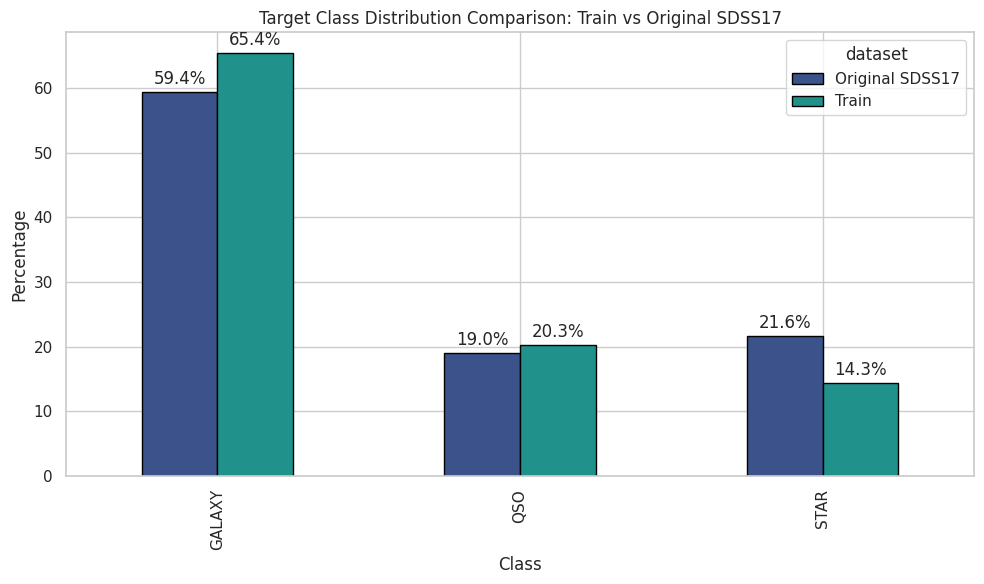

In [3]:
# Optional loading of the original SDSS17 dataset
orig_paths = [
    '/kaggle/input/datasets/fedesoriano/stellar-classification-dataset-sdss17/star_classification.csv',
    '../data/star_classification.csv',
    './data/star_classification.csv'
]
orig_path = next((p for p in orig_paths if os.path.exists(p)), None)

if orig_path:
    print(f"Original dataset found at: {orig_path}")
    orig = pd.read_csv(orig_path)
    print(f"Original shape: {orig.shape}")
    
    # Drop outlier row at index 79543 containing -9999.0 value
    outliers = orig[orig[['u', 'z', 'g']].eq(-9999.0).any(axis=1)]
    if not outliers.empty:
        print(f"Dropping {len(outliers)} outlier rows containing -9999.0...")
        orig = orig.drop(outliers.index).reset_index(drop=True)
        
    # Plot class distribution percentage comparison: Train vs Orig
    combined = pd.concat([
        train.assign(dataset='Train'),
        orig.assign(dataset='Original SDSS17')
    ])
    pct = pd.crosstab(combined['class'], combined['dataset'], normalize='columns') * 100
    
    fig, ax = plt.subplots(figsize=(10, 6))
    pct.plot(kind='bar', ax=ax, edgecolor='black', color=['#3b528b', '#21918c'])
    
    # Add values on top of bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', padding=3)
        
    ax.set_title('Target Class Distribution Comparison: Train vs Original SDSS17')
    ax.set_xlabel('Class')
    ax.set_ylabel('Percentage')
    plt.tight_layout()
    plt.show()
else:
    print("Original dataset not found. Mount \'fedesoriano/stellar-classification-dataset-sdss17\' on Kaggle to enable comparative analysis.")

## 2. Feature Profiling

Previewing the raw data schema. The target variable is the categorical feature `class` (`GALAXY`, `STAR`, `QSO`). Features consist of coordinates (`alpha`, `delta`), photometric bands (`u`, `g`, `r`, `i`, `z`), and catalog categoricals (`spectral_type`, `galaxy_population`).

In [4]:
print("\nTrain Dataset Head:")
display(train.head())

print("\nTest Dataset Head:")
display(test.head())

print("\nSample Submission Dataset Head:")
display(submission.head())


--- Train Dataset Head ---


,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY



--- Test Dataset Head ---


,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population
0,577347,120.719779,23.924249,23.668066,21.951680,21.086183,20.180032,19.202124,0.429042,G/K,Red_Sequence
1,577348,219.414419,42.171651,24.902933,22.338822,20.732163,19.860330,19.687691,0.867305,M,Red_Sequence
2,577349,173.568731,-1.756400,19.427591,18.474633,17.551314,16.570674,16.176765,0.224234,G/K,Blue_Cloud
3,577350,184.903993,-1.411074,23.121029,21.526855,20.670159,20.417633,20.699095,0.066507,G/K,Red_Sequence
4,577351,222.487816,15.381403,25.094282,22.643981,21.123173,19.439500,19.094158,0.977218,M,Red_Sequence



--- Sample Submission Dataset Head ---


,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,GALAXY
4,577351,GALAXY


## 3. Class Imbalance & Metric

The target variable `class` exhibits significant distribution skew:
- `GALAXY`: ~65.4% (Majority class)
- `QSO` (Quasar): ~20.3%
- `STAR`: ~14.3% (Minority class)

### 3.1. Balanced Accuracy Metric
Because of this imbalance, the competition uses **Balanced Accuracy** as the primary evaluation metric. Mathematically:
$$\text{Balanced Accuracy} = \frac{1}{3} \left( \text{Recall}_{\text{Galaxy}} + \text{Recall}_{\text{QSO}} + \text{Recall}_{\text{Star}} \right)$$
where each class recall is defined as:
$$\text{Recall}_c = \frac{\text{True Positives}_c}{\text{True Positives}_c + \text{False Negatives}_c}$$

### 3.2. Class-Weighted Strategy
Standard cross-entropy loss optimization will bias models toward the majority `GALAXY` class. To counter this, we must align our validation metrics with the unweighted recall average. A misclassified `STAR` is mathematically **4.5x** more expensive than a misclassified `GALAXY` (\frac{65.4\%}{14.3\%} \approx 4.57$). We will implement sample-weight and class-weight balancing configurations inside our model training scripts.

         Count  Percentage
class                     
GALAXY  377480   65.381824
QSO     117143   20.289878
STAR     82724   14.328298


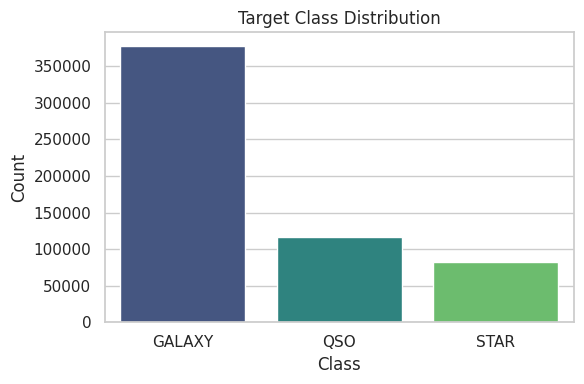

In [5]:
counts = train['class'].value_counts()
pcts = train['class'].value_counts(normalize=True) * 100
dist_df = pd.DataFrame({'Count': counts, 'Percentage': pcts})
print(dist_df)

plt.figure(figsize=(6, 4))
sns.countplot(data=train, x='class', hue='class', palette='viridis', legend=False)
plt.title('Target Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**3D Cosmology Reconstruction**

By treating redshift as a cosmological distance proxy, we convert spherical angles (Right Ascension $\alpha$, Declination $\delta$) and distance (redshift $z$) into 3D Cartesian coordinates. This places stars, galaxies, and quasars in a physical map of the observed universe.

In [ ]:
# Prepare coordinates scaled by redshift
space = train.sample(10000, random_state=42).copy()
alpha_rad = np.radians(space['alpha'])
delta_rad = np.radians(space['delta'])
z_proxy = space['redshift']

space['x_scaled'] = z_proxy * np.cos(delta_rad) * np.cos(alpha_rad)
space['y_scaled'] = z_proxy * np.cos(delta_rad) * np.sin(alpha_rad)
space['z_scaled'] = z_proxy * np.sin(delta_rad)

# Draw interactive 3D scatter plot
fig = px.scatter_3d(
    space,
    x='x_scaled',
    y='y_scaled',
    z='z_scaled',
    color='class',
    opacity=0.6,
    color_discrete_sequence=['#440154', '#21918c', '#fde725'],
    title='3D Cosmological Reconstruction: Stars, Galaxies & Quasars'
)
fig.update_traces(marker=dict(size=2))
fig.update_layout(
    margin=dict(l=0, r=0, b=0, t=40),
    scene=dict(
        xaxis_title='X (Redshift-Scaled)',
        yaxis_title='Y (Redshift-Scaled)',
        zaxis_title='Z (Redshift-Scaled)'
    )
)
fig.show()

## 4. Redshift Cosmological Context

Redshift ($z$) measures the stretching of light wavelengths toward redder frequencies due to the expansion of the universe (Hubble's Law). The astronomical profiles of our classes dictate their redshift distributions:

$$\text{Redshift } z = \frac{\lambda_{\text{observed}} - \lambda_{\text{emit}}}{\lambda_{\text{emit}}}$$

### 4.1. Class Redshift Profiles
1. **Stars ($z \approx 0$):** Stars are gravitationally bound within the Milky Way galaxy. They do not expand with the cosmic web, resulting in a redshift distribution tightly centered around 0 (median: $0.00007$).
2. **Galaxies ($0 < z \le 1.0$):** Galaxies reside outside our local group and recede from us, exhibiting low-to-mid range redshift values corresponding to light travel distance (median: $0.077$).
3. **Quasars / QSOs ($1.5 \le z \le 7.0$):** Quasars are highly energetic active galactic nuclei (AGN) powered by supermassive black holes. Visible only at cosmological distances, they exhibit high redshift distributions (median: $1.72$, stretching up to $7+$).

### 4.2. Class Overlaps & Boundaries
- **Galaxy/Star Overlap ($z \le 0$):** Local group galaxies (such as Andromeda) can exhibit negative redshift due to blueshift. Separating local galaxies from stars requires relying on photometric magnitudes.
- **Galaxy/QSO Overlap ($z \ge 1.0$):** Starburst galaxies at extreme distances show redshifts that overlap with the quasar region. We must utilize spectral indicators to partition these targets.

--- Redshift Summary by Class ---
           count      mean       std       min       25%       50%       75%  \
class                                                                          
GALAXY  377480.0  0.509026  0.309139 -0.009934  0.267017  0.481960  0.715023   
QSO     117143.0  1.875641  1.069731  0.000100  1.131805  1.798886  2.506401   
STAR     82724.0  0.068115  0.064476 -0.009970  0.021884  0.056492  0.102069   

             max  
class             
GALAXY  6.860273  
QSO     7.010780  
STAR    5.445217  


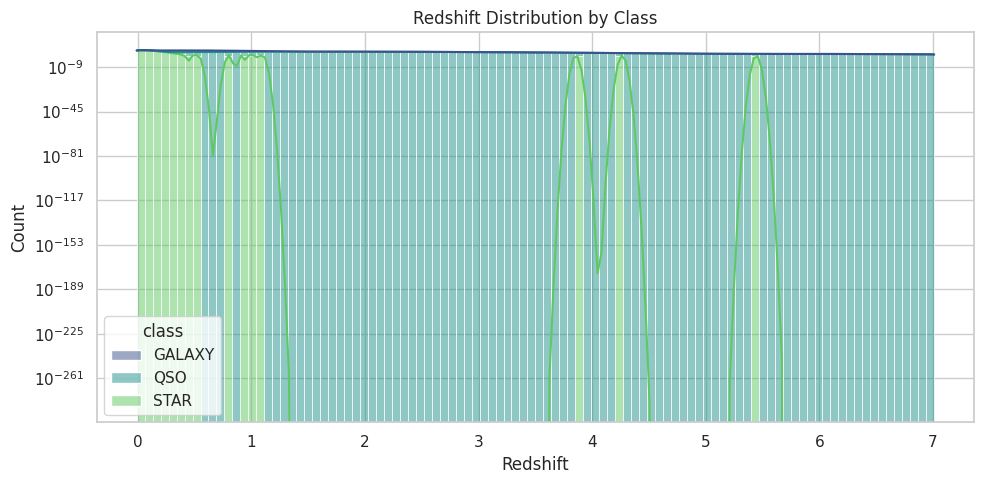

In [6]:
print("Redshift Summary by Class:")
print(train.groupby('class')['redshift'].describe())

plt.figure(figsize=(10, 5))
sns.histplot(data=train, x='redshift', hue='class', kde=True, bins=100, palette='viridis', multiple='stack')
plt.title('Redshift Distribution by Class')
plt.xlabel('Redshift')
plt.ylabel('Count')
plt.yscale('log') # Using log scale due to broad range and peak density differences
plt.tight_layout()
plt.show()

### 4.3. 3D Universe Reconstruction

By treating redshift as a cosmological distance proxy, we convert spherical angles (Right Ascension $\alpha$, Declination $\delta$) and distance (redshift $z$) into 3D Cartesian coordinates. This places stars, galaxies, and quasars in a physical map of the observed universe.

In [7]:
# Prepare coordinates scaled by redshift
space = train.sample(10000, random_state=42).copy()
alpha_rad = np.radians(space['alpha'])
delta_rad = np.radians(space['delta'])
z_proxy = space['redshift']

space['x_scaled'] = z_proxy * np.cos(delta_rad) * np.cos(alpha_rad)
space['y_scaled'] = z_proxy * np.cos(delta_rad) * np.sin(alpha_rad)
space['z_scaled'] = z_proxy * np.sin(delta_rad)

# Draw interactive 3D scatter plot
fig = px.scatter_3d(
    space,
    x='x_scaled',
    y='y_scaled',
    z='z_scaled',
    color='class',
    opacity=0.6,
    color_discrete_sequence=['#440154', '#21918c', '#fde725'],
    title='3D Cosmological Reconstruction: Stars, Galaxies & Quasars'
)
fig.update_traces(marker=dict(size=2))
fig.update_layout(
    margin=dict(l=0, r=0, b=0, t=40),
    scene=dict(
        xaxis_title='X (Redshift-Scaled)',
        yaxis_title='Y (Redshift-Scaled)',
        zaxis_title='Z (Redshift-Scaled)'
    )
)
fig.show()

### 6.5. Spherical Celestial Projection (Mollweide)

Plotting spherical coordinates on a flat plane introduces distortion. We use a **Mollweide projection** to correctly map Right Ascension and Declination onto a celestial sphere, with point colors representing redshift.

In [ ]:
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection='mollweide')

df_sample = train.sample(20000, random_state=42).copy()
# Mollweide projection requires alpha mapped from [0, 360] -> [-180, 180] in radians
alpha_rad = np.radians(df_sample['alpha'] - 180)
delta_rad = np.radians(df_sample['delta'])

scatter = ax.scatter(
    alpha_rad,
    delta_rad,
    c=df_sample['redshift'],
    s=1.5,
    cmap='viridis',
    alpha=0.6
)
ax.grid(True)
plt.title('Spherical Celestial Map of Observed Objects (Mollweide Projection)')
plt.colorbar(scatter, label='Redshift (z)')
plt.tight_layout()
plt.show()

## 5. Color Indices as Proxies

Magnitudes represent the brightness of light captured through filters ($u$, $g$, $r$, $i$, $z$). Direct magnitudes depend heavily on object distance and absolute luminosity. To extract intrinsic surface properties, astronomers subtract adjacent filter magnitudes to form **Color Indices** (e.g., $u-g$, $g-r$, $r-i$, $i-z$).

### 5.1. Color-Temperature Physics
- **Blackbody Stellar Curves:** Stars radiate thermal energy close to a blackbody curve. Cool stars (Class M) peak in redder bands (large $u-g$), while hot stars (Class O/B) emit predominantly in UV/blue bands (low/negative $u-g$).
- **Non-Thermal Quasar Power-Laws:** Quasars display a power-law spectrum driven by gravitational accretion disks, overlaid with strong Lyman-alpha emission lines. This places them in unique sectors of multi-dimensional color space (e.g. $u-g$ vs $g-r$ color-color plot).

### 5.2. Color-Color Distributions

We plot a scatter plot comparing the engineered color indices $u-g$ and $g-r$ to empirically inspect how the target classes partition in color space.

### 7.5. Categorical Feature Associations (Cramer's V)

To evaluate the strength of associations between our categorical catalog columns (`spectral_type`, `galaxy_population`) and the target `class`, we compute **Cramer's V** (a chi-square based measure of association) and plot the correlation matrix.

In [ ]:
def calculate_cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

# Features to check association
assoc_cols = ['spectral_type', 'galaxy_population', 'class']
corr_matrix = pd.DataFrame(np.eye(len(assoc_cols)), index=assoc_cols, columns=assoc_cols)

for row_idx in range(len(assoc_cols)):
    for col_idx in range(row_idx + 1, len(assoc_cols)):
        val = calculate_cramers_v(train[assoc_cols[row_idx]], train[assoc_cols[col_idx]])
        corr_matrix.iloc[row_idx, col_idx] = val
        corr_matrix.iloc[col_idx, row_idx] = val

plt.figure(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='viridis', vmin=0, vmax=1, square=True)
plt.title("Categorical Association Heatmap (Cramer's V)")
plt.tight_layout()
plt.show()

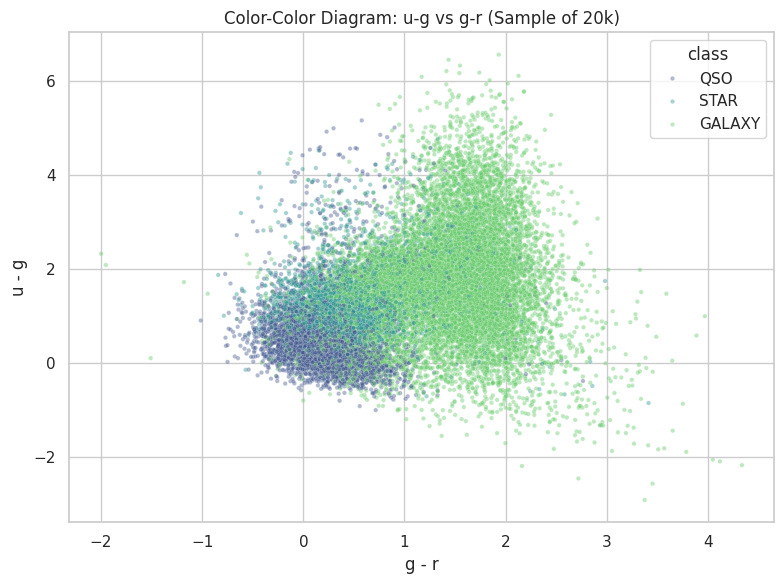

In [8]:
# Engineering color index differences
train['u_g'] = train['u'] - train['g']
train['g_r'] = train['g'] - train['r']
train['r_i'] = train['r'] - train['i']
train['i_z'] = train['i'] - train['z']

# Sample data for plotting to keep memory/runtime small
sample = train.sample(20000, random_state=42)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=sample, x='g_r', y='u_g', hue='class', palette='viridis', alpha=0.4, s=10)
plt.title('Color-Color Diagram: u-g vs g-r (Sample of 20k)')
plt.xlabel('g - r')
plt.ylabel('u - g')
plt.tight_layout()
plt.show()

## 6. Celestial Coordinate Geometry

Positional features are recorded in Right Ascension (\alpha or `alpha`) and Declination (\delta or `delta`). Right Ascension is a circular angle ranging from $0^\circ$ to $360^\circ$.

### 6.1. Coordinate Wrapping Boundary
Decision tree algorithms make orthogonal axis splits. When dividing on a circular feature like `alpha`, a boundary split at $0^\circ / 360^\circ$ splits adjacent spatial coordinates (e.g., $359.9^\circ$ and $0.1^\circ$ are physically close but placed at opposite ends of the feature scale). This forces trees to construct unnecessary splits to merge spatial regions.

### 6.2. 3D Sphere Projection
To resolve this discontinuity, we project the angles into Cartesian coordinates on a 3D unit sphere:
$$x = \cos(\delta) \cos(\alpha)$$
$$y = \cos(\delta) \sin(\alpha)$$
$$z = \sin(\delta)$$
*(Note: Angles must be converted to radians).* This maps angular spatial coordinates into a continuous coordinate space, permitting decision trees to split on local spatial proximity.

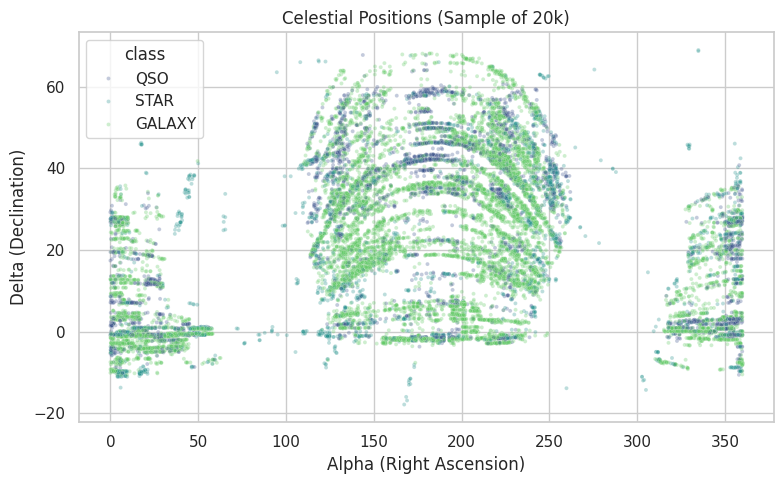

In [9]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=sample, x='alpha', y='delta', hue='class', palette='viridis', alpha=0.3, s=8)
plt.title('Celestial Positions (Sample of 20k)')
plt.xlabel('Alpha (Right Ascension)')
plt.ylabel('Delta (Declination)')
plt.tight_layout()
plt.show()

### 6.3. Celestial Mollweide Projection

Plotting spherical coordinates on a flat plane introduces distortion. We use a **Mollweide projection** to correctly map Right Ascension and Declination onto a celestial sphere, with point colors representing redshift.

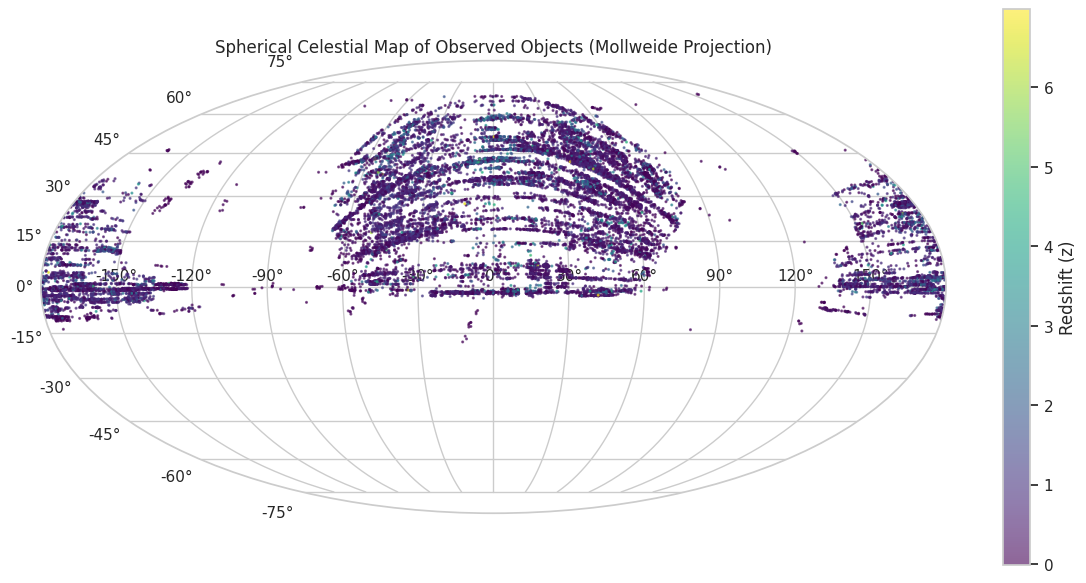

In [10]:
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection='mollweide')

df_sample = train.sample(20000, random_state=42).copy()
# Mollweide projection requires alpha mapped from [0, 360] -> [-180, 180] in radians
alpha_rad = np.radians(df_sample['alpha'] - 180)
delta_rad = np.radians(df_sample['delta'])

scatter = ax.scatter(
    alpha_rad,
    delta_rad,
    c=df_sample['redshift'],
    s=1.5,
    cmap='viridis',
    alpha=0.6
)
ax.grid(True)
plt.title('Spherical Celestial Map of Observed Objects (Mollweide Projection)')
plt.colorbar(scatter, label='Redshift (z)')
plt.tight_layout()
plt.show()

## 7. Categorical Sub-Types

The dataset includes categorical features mapping physical sub-types:
1. **Spectral Type (`spectral_type`):** Identifies temperature classes (`O`, `B`, `A`, `F`, `G`, `K`, `M`). Hot classes (`O/B`) indicate young massive stars or energetic AGN (Quasars). Passive classes (`M`) correlate with cool stars or red sequence galaxies.
2. **Galaxy Population (`galaxy_population`):** Splits galaxies into the passively evolving **Red Sequence** (mostly older elliptical galaxies) and star-forming **Blue Cloud** populations.

### 7.1. Count Profiles

We visualize the distribution of our categorical attributes (`spectral_type` and `galaxy_population`) broken down by the target class to inspect class frequencies.

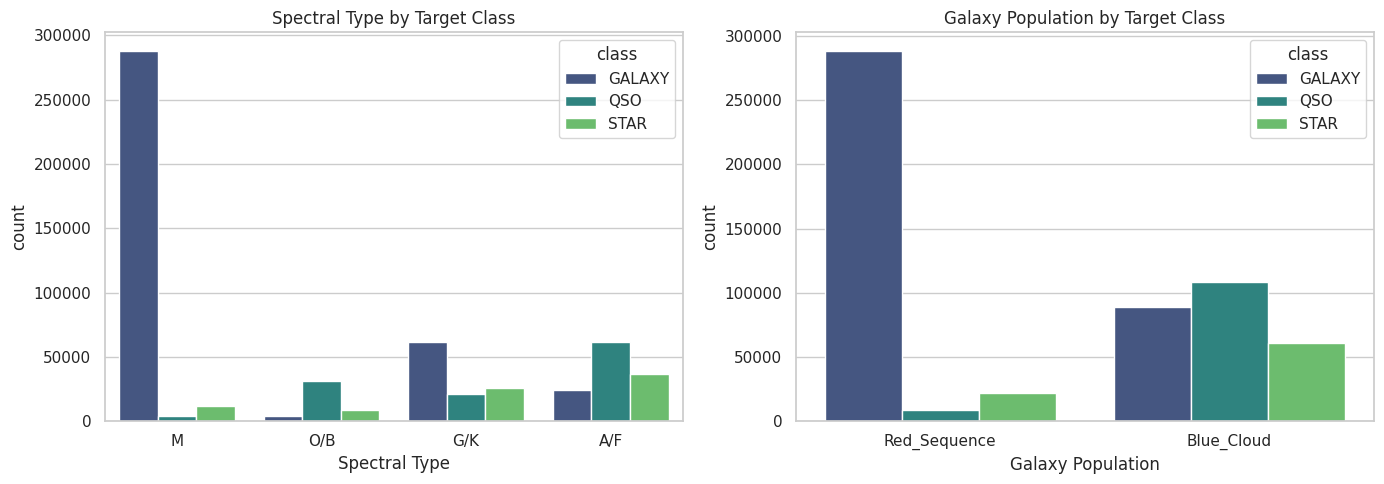

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=train, x='spectral_type', hue='class', palette='viridis', ax=axes[0])
axes[0].set_title('Spectral Type by Target Class')
axes[0].set_xlabel('Spectral Type')

sns.countplot(data=train, x='galaxy_population', hue='class', palette='viridis', ax=axes[1])
axes[1].set_title('Galaxy Population by Target Class')
axes[1].set_xlabel('Galaxy Population')

plt.tight_layout()
plt.show()

### 7.2. Cramer's V Associations

To evaluate the strength of associations between our categorical catalog columns (`spectral_type`, `galaxy_population`) and the target `class`, we compute **Cramer's V** (a chi-square based measure of association) and plot the correlation matrix.

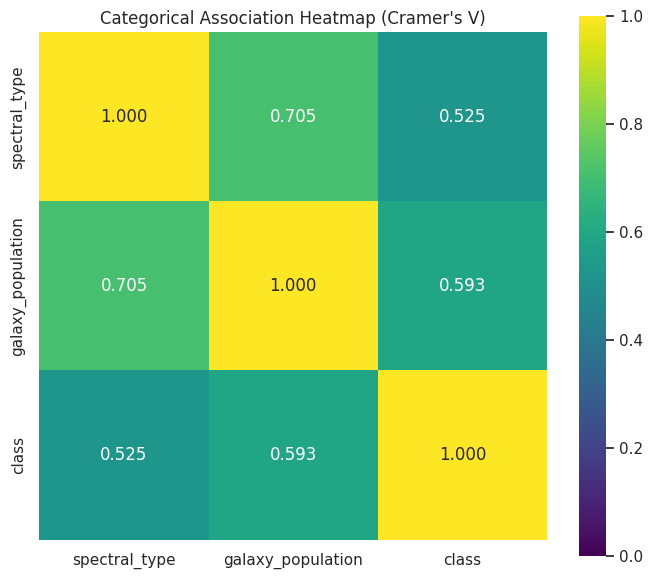

In [12]:
def calculate_cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

# Features to check association
assoc_cols = ['spectral_type', 'galaxy_population', 'class']
corr_matrix = pd.DataFrame(np.eye(len(assoc_cols)), index=assoc_cols, columns=assoc_cols)

for row_idx in range(len(assoc_cols)):
    for col_idx in range(row_idx + 1, len(assoc_cols)):
        val = calculate_cramers_v(train[assoc_cols[row_idx]], train[assoc_cols[col_idx]])
        corr_matrix.iloc[row_idx, col_idx] = val
        corr_matrix.iloc[col_idx, row_idx] = val

plt.figure(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='viridis', vmin=0, vmax=1, square=True)
plt.title("Categorical Association Heatmap (Cramer's V)")
plt.tight_layout()
plt.show()

## 8. Strategic Takeaways

Based on our exploratory data analysis, we establish the following strategic directives for our modeling pipeline:

1. **Address Severe Class Imbalance (Metric Alignment)**
   * **Observation:** The target classes are heavily skewed (`GALAXY`: ~65.4%, `QSO`: ~20.3%, `STAR`: ~14.3%).
   * **Guideline:** Since our target metric is **Balanced Accuracy**, standard cross-entropy loss will overfit the majority class. We must apply inverse class weights. A misclassified `STAR` is **~4.5x** more costly than a misclassified `GALAXY`. We will configure `class_weight='balanced'` in LightGBM, `auto_class_weights='Balanced'` in CatBoost, and custom sample weights in XGBoost.

2. **Handle Redshift Cosmological Artifacts (Unphysical Shifts)**
   * **Observation:** Over 75% of the samples labeled as `STAR` have redshift $z > 0.02$, with a maximum of $5.44$ (which is physically impossible for Milky Way stars).
   * **Guideline:** The model cannot rely on a simple redshift cutoff to isolate stars. It must learn to combine redshift with color indices and spectral codes to resolve synthetic data noise.

3. **Leverage Photometric Color Indices**
   * **Observation:** Absolute magnitudes ($u, g, r, i, z$) depend on object distance and absolute luminosity. Color indices (differences between adjacent filter bands) act as distance-invariant estimators of radiation curves.
   * **Guideline:** We will engineer all 10 color index differences ($u-g, g-r, r-i, i-z, u-r, g-i, r-z, u-i, g-z, u-z$) to map physical surface properties and emission line signatures.

4. **Prevent Coordinate Wrap-Around Boundaries**
   * **Observation:** Right Ascension (`alpha`) is a circular longitude ($0^\circ \to 360^\circ$), where $359.9^\circ$ is spatially adjacent to $0.1^\circ$. Decision tree splits treat these boundary extremes as opposites.
   * **Guideline:** We project celestial coordinates ($\alpha, \delta$) into 3D Cartesian coordinates ($x, y, z$) on a unit sphere to resolve boundary discontinuities.